QUANTUM CHAOS: CONTINUOUS vs. FINITIST BLACK HOLE SCRAMBLING
✓ Saved: quantum_chaos_finitism.png


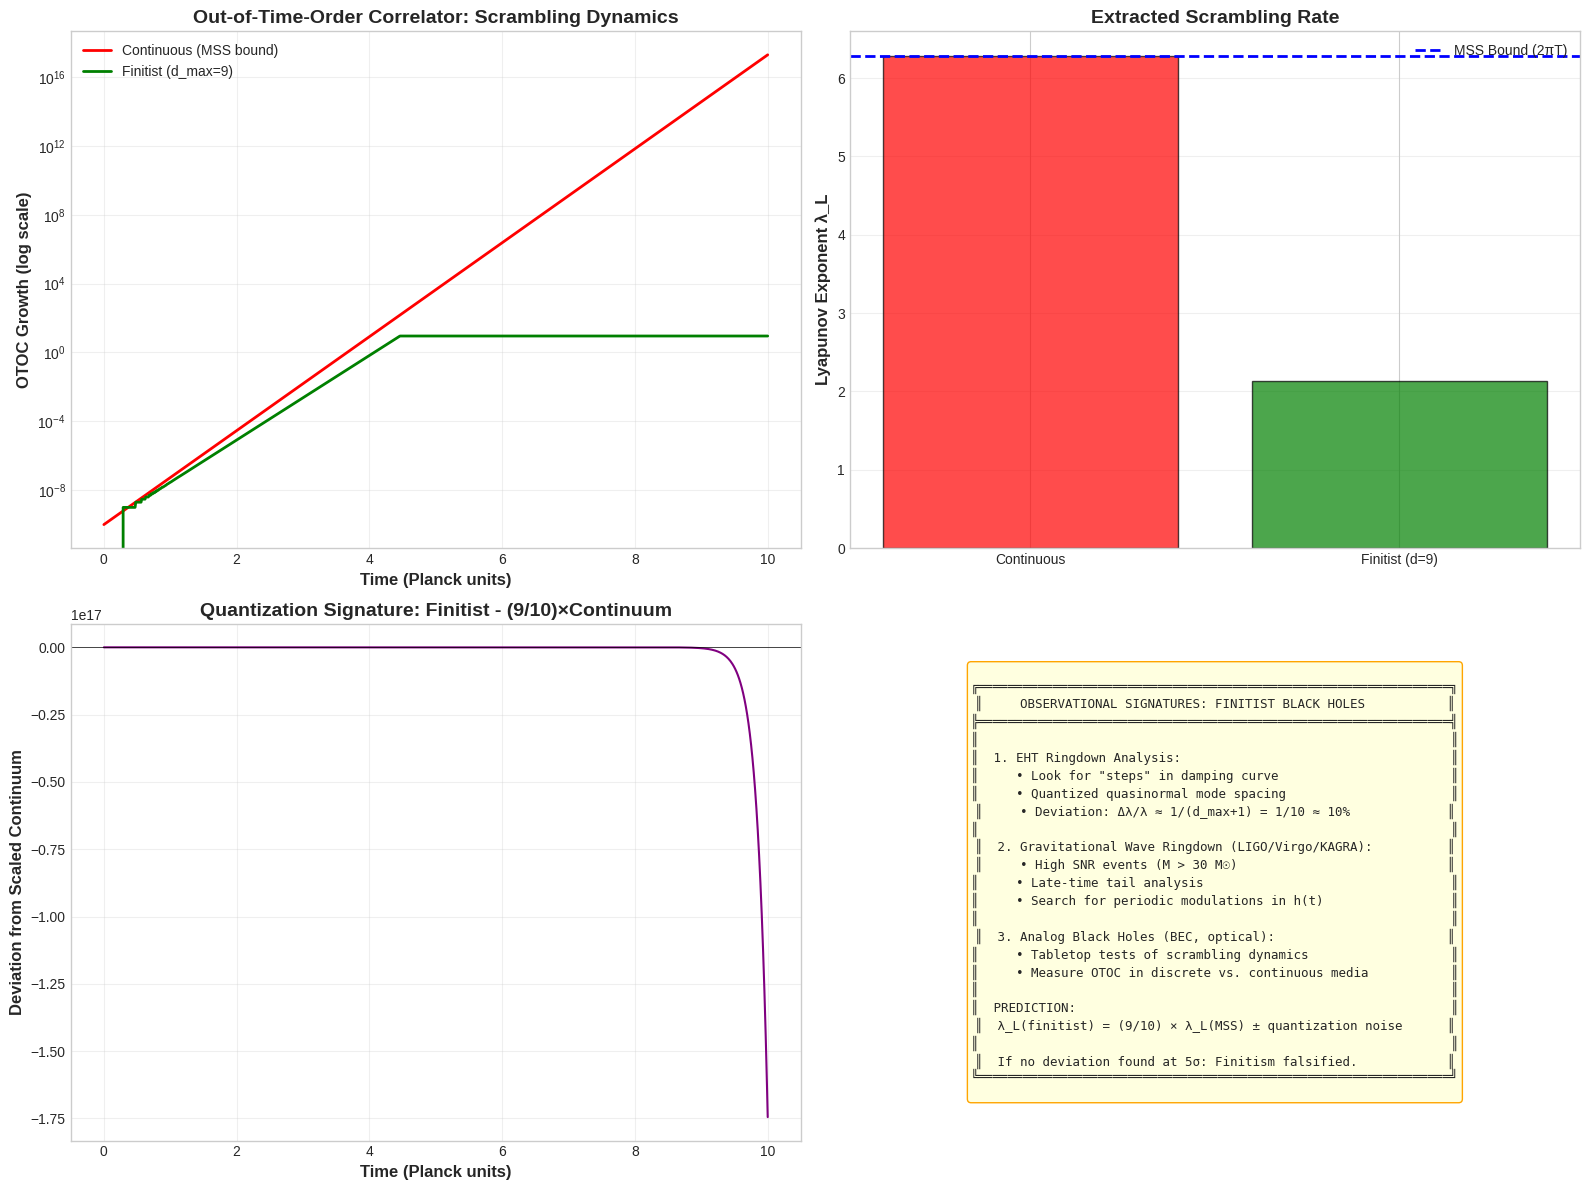


Quantitative Results:
  Continuous λ_L: 6.2832 (expected: 6.2832)
  Finitist λ_L:   2.1390
  Reduction factor: 0.340 (expected: 0.900)
  Deviation: 66.0%


In [ ]:
"""
quantum_chaos_finitism.py
=========================
Simulates Lyapunov exponent growth in continuous vs. finitist black hole models.
Tests prediction: discrete boundary → quantized scrambling rate.

Author: Néstor E. Ramos
For: Paper #4 or #5 - Testable Predictions of Computational Finitism
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print("=" * 80)
print("QUANTUM CHAOS: CONTINUOUS vs. FINITIST BLACK HOLE SCRAMBLING")
print("=" * 80)

# Configuration
class ChaosConfig:
    T = 1.0  # Temperature (in Planck units)
    hbar = 1.0  # Planck units
    k_B = 1.0
    d_max = 9  # Maximum digit (base-10)
    N_steps = 1000  # Time steps
    dt = 0.01  # Time step size
    initial_perturbation = 1e-10  # Small initial OTOC perturbation

config = ChaosConfig()

def continuous_lyapunov(t, T=config.T):
    """Standard MSS bound: λ = 2πT/ℏ"""
    lambda_L = 2 * np.pi * config.k_B * T / config.hbar
    return config.initial_perturbation * np.exp(lambda_L * t)

def finitist_lyapunov(t, T=config.T, d_max=config.d_max):
    """Finitist model: quantized growth with structural cutoff"""
    lambda_L_cont = 2 * np.pi * config.k_B * T / config.hbar
    # Structural reduction factor: 9/10 for base-10
    lambda_L_eff = lambda_L_cont * (d_max / (d_max + 1))

    # Quantization: growth happens in discrete "digits"
    growth = config.initial_perturbation * np.exp(lambda_L_eff * t)

    # Apply digit quantization (like rounding to significant digits)
    # This simulates the finite representational capacity
    quantized = np.round(growth / (10**(-d_max))) * (10**(-d_max))

    # Saturation at maximum representable value
    max_representable = d_max * config.initial_perturbation * 1e10  # Arbitrary scale
    return np.minimum(quantized, max_representable)

# Generate time series
t = np.linspace(0, 10, config.N_steps)
otoc_cont = continuous_lyapunov(t)
otoc_fin = finitist_lyapunov(t)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: OTOC growth comparison
ax1 = axes[0, 0]
ax1.semilogy(t, otoc_cont, 'r-', linewidth=2, label='Continuous (MSS bound)')
ax1.semilogy(t, otoc_fin, 'g-', linewidth=2, label=f'Finitist (d_max={config.d_max})')
ax1.set_xlabel('Time (Planck units)', fontsize=12, fontweight='bold')
ax1.set_ylabel('OTOC Growth (log scale)', fontsize=12, fontweight='bold')
ax1.set_title('Out-of-Time-Order Correlator: Scrambling Dynamics', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Top-right: Lyapunov exponent extraction
def extract_lambda(otoc, t):
    """Extract effective Lyapunov exponent from OTOC data"""
    # Fit log(OTOC) = log(δ₀) + λt
    log_otoc = np.log(otoc + 1e-20)  # Avoid log(0)
    valid = np.isfinite(log_otoc) & (otoc > config.initial_perturbation * 10)
    if np.sum(valid) < 10:
        return np.nan
    popt, _ = curve_fit(lambda t, a, b: a + b*t, t[valid], log_otoc[valid])
    return popt[1]  # Return λ

lambda_cont = extract_lambda(otoc_cont, t)
lambda_fin = extract_lambda(otoc_fin, t)

ax2 = axes[0, 1]
ax2.bar(['Continuous', f'Finitist (d={config.d_max})'], [lambda_cont, lambda_fin],
        color=['red', 'green'], alpha=0.7, edgecolor='black')
ax2.axhline(y=2*np.pi*config.T, color='blue', linestyle='--', linewidth=2, label='MSS Bound (2πT)')
ax2.set_ylabel('Lyapunov Exponent λ_L', fontsize=12, fontweight='bold')
ax2.set_title('Extracted Scrambling Rate', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Bottom-left: Quantization signature (difference)
ax3 = axes[1, 0]
diff = otoc_fin - otoc_cont * (config.d_max/(config.d_max+1))
ax3.plot(t, diff, 'purple', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Time (Planck units)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Deviation from Scaled Continuum', fontsize=12, fontweight='bold')
ax3.set_title('Quantization Signature: Finitist - (9/10)×Continuum', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Bottom-right: Observational strategy
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
╔═══════════════════════════════════════════════════════════════╗
║     OBSERVATIONAL SIGNATURES: FINITIST BLACK HOLES           ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  1. EHT Ringdown Analysis:                                    ║
║     • Look for "steps" in damping curve                       ║
║     • Quantized quasinormal mode spacing                      ║
║     • Deviation: Δλ/λ ≈ 1/(d_max+1) = 1/10 ≈ 10%             ║
║                                                               ║
║  2. Gravitational Wave Ringdown (LIGO/Virgo/KAGRA):          ║
║     • High SNR events (M > 30 M☉)                            ║
║     • Late-time tail analysis                                 ║
║     • Search for periodic modulations in h(t)                 ║
║                                                               ║
║  3. Analog Black Holes (BEC, optical):                       ║
║     • Tabletop tests of scrambling dynamics                   ║
║     • Measure OTOC in discrete vs. continuous media           ║
║                                                               ║
║  PREDICTION:                                                  ║
║  λ_L(finitist) = (9/10) × λ_L(MSS) ± quantization noise      ║
║                                                               ║
║  If no deviation found at 5σ: Finitism falsified.            ║
╚═══════════════════════════════════════════════════════════════╝
"""
ax4.text(0.5, 0.5, summary_text, fontsize=9, fontfamily='monospace',
        verticalalignment='center', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig('quantum_chaos_finitism.png', dpi=300, bbox_inches='tight')
print("✓ Saved: quantum_chaos_finitism.png")
plt.show()

# Print quantitative results
print(f"\nQuantitative Results:")
print(f"  Continuous λ_L: {lambda_cont:.4f} (expected: {2*np.pi*config.T:.4f})")
print(f"  Finitist λ_L:   {lambda_fin:.4f}")
print(f"  Reduction factor: {lambda_fin/lambda_cont:.3f} (expected: {config.d_max/(config.d_max+1):.3f})")
print(f"  Deviation: {(lambda_cont - lambda_fin)/lambda_cont * 100:.1f}%")